# Single‑Cell RNA‑seq Pipeline with Scanpy

Used `bone_marrow.h5ad` dataset.


## 0. Installation

In [1]:
!pip -q install scanpy[leiden] umap-learn leidenalg python-igraph anndata pandas matplotlib scikit-learn scikit-misc

!pip -q install celltypist decoupler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 76.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 221.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.9/120.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━

## 1. Imports & settings

In [2]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, figsize=(6,6))

## 2. Load data

In [3]:
from google.colab import files
uploaded = files.upload()
# Then access it using the filename, e.g. "bone_marrow.h5ad"

Saving bone_marrow.h5ad to bone_marrow.h5ad


In [4]:
adata = sc.read_h5ad('bone_marrow.h5ad')
adata

AnnData object with n_obs × n_vars = 14783 × 17374
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'n_cells', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'doi', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_tsne', 'X_umap'

## 3. Fix gene names
Your dataset stores gene symbols in `adata.var['feature_name']`. Scanpy uses `adata.var_names`, so we overwrite it with the true symbols.

In [5]:
adata.var_names = adata.var['feature_name'].astype(str)
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 14783 × 17374
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'n_cells', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'doi', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_tsne', 'X_umap'

## Addendum: Prepare Ensembl ↔ Gene Symbol mapping for decoupler
CZI/CellxGene datasets often use Ensembl IDs, but PanglaoDB markers are gene symbols. This block downloads a mapping table and converts PanglaoDB markers to Ensembl IDs so decoupler enrichment works correctly.

**Insert location:** after gene-name fixing and before dimensionality reduction.

In [6]:
!wget -O result.txt 'http://www.ensembl.org/biomart/martservice?query=<?xml version="1.0" encoding="UTF-8"?><!DOCTYPE Query><Query  virtualSchemaName = "default" formatter = "CSV" header = "0" uniqueRows = "0" count = "" datasetConfigVersion = "0.6" ><Dataset name = "hsapiens_gene_ensembl" interface = "default" ><Attribute name = "ensembl_gene_id" /><Attribute name = "external_gene_name" /></Dataset></Query>'
# Downloads a 2-column Ensembl↔symbol table to result.txt

--2025-11-27 19:58:31--  http://www.ensembl.org/biomart/martservice?query=%3C?xml%20version=%221.0%22%20encoding=%22UTF-8%22?%3E%3C!DOCTYPE%20Query%3E%3CQuery%20%20virtualSchemaName%20=%20%22default%22%20formatter%20=%20%22CSV%22%20header%20=%20%220%22%20uniqueRows%20=%20%220%22%20count%20=%20%22%22%20datasetConfigVersion%20=%20%220.6%22%20%3E%3CDataset%20name%20=%20%22hsapiens_gene_ensembl%22%20interface%20=%20%22default%22%20%3E%3CAttribute%20name%20=%20%22ensembl_gene_id%22%20/%3E%3CAttribute%20name%20=%20%22external_gene_name%22%20/%3E%3C/Dataset%3E%3C/Query%3E
Resolving www.ensembl.org (www.ensembl.org)... 193.62.193.83
Connecting to www.ensembl.org (www.ensembl.org)|193.62.193.83|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘result.txt’

result.txt              [      <=>           ]   1.71M  1.44MB/s    in 1.2s    

2025-11-27 19:58:32 (1.44 MB/s) - ‘result.txt’ saved [1795328]



In [7]:
import pandas as pd

ensembl_var = pd.read_csv('result.txt', header=None)
ensembl_var.columns = ['ensembl_gene_id', 'gene_name']
ensembl_var.head()

,ensembl_gene_id,gene_name
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [8]:
!pip -q install decoupler
import decoupler as dc

# Query Omnipath and get PanglaoDB markers
markers = dc.op.resource(name='PanglaoDB', organism='human')

# Optional: keep canonical markers only
# markers = markers[markers['canonical_marker']]

# Remove duplicates
markers = markers[~markers.duplicated(['cell_type','genesymbol'])]

# Format for decoupler
markers = markers.rename(columns={'cell_type':'source','genesymbol':'target'})
markers = markers[['source','target']]
markers.head()

,source,target
,,
0,Hepatocytes,A1CF
1,Germ cells,A2APA5
2,Bergmann glia,A2M
3,Mast cells,A3FIN4
4,Mast cells,A4GALT


In [9]:
# Convert marker gene symbols -> Ensembl IDs
markers = markers.merge(ensembl_var, left_on='target', right_on='gene_name', how='left')
markers = markers.drop(columns=['target'])
markers = markers[~markers.duplicated(['source','ensembl_gene_id'])]
markers = markers.rename(columns={'ensembl_gene_id':'target'})
markers = markers[['source','target']].dropna()
markers.head()

,source,target
0,Hepatocytes,ENSG00000148584
2,Bergmann glia,ENSG00000175899
4,Mast cells,ENSG00000128274
6,Interneurons,ENSG00000115977
7,Neurons,ENSG00000115977


## 4. QC: flag mitochondrial / ribosomal / hemoglobin genes

In [11]:
# Mito genes
adata.var['MT'] = adata.var_names.str.upper().str.startswith('MT-')
# Ribosomal genes
adata.var['RIBO'] = adata.var_names.str.upper().str.startswith(('RPS','RPL'))
# Hemoglobin genes (optional)
adata.var['HB'] = adata.var_names.str.upper().str.match(r'^HB(?!P)')

sc.pp.calculate_qc_metrics(adata, qc_vars=['MT','RIBO','HB'], inplace=True)
adata.obs[['total_counts','n_genes_by_counts','pct_counts_MT','pct_counts_RIBO']].describe()

,total_counts,n_genes_by_counts,pct_counts_MT,pct_counts_RIBO
count,14783.000000,14783.00000,14783.000000,14783.000000
mean,8778.205078,971.03362,1.521959,11.055460
std,3277.343506,467.76228,0.537766,3.609177
min,3166.032471,300.00000,0.000000,0.940382
25%,6611.790527,681.00000,1.168874,8.542548
50%,8328.338867,888.00000,1.423523,10.594313
75%,10067.967285,1107.00000,1.771708,13.455132
max,31207.701172,5422.00000,4.927056,25.379330


### 4b. QC plots (choose thresholds)

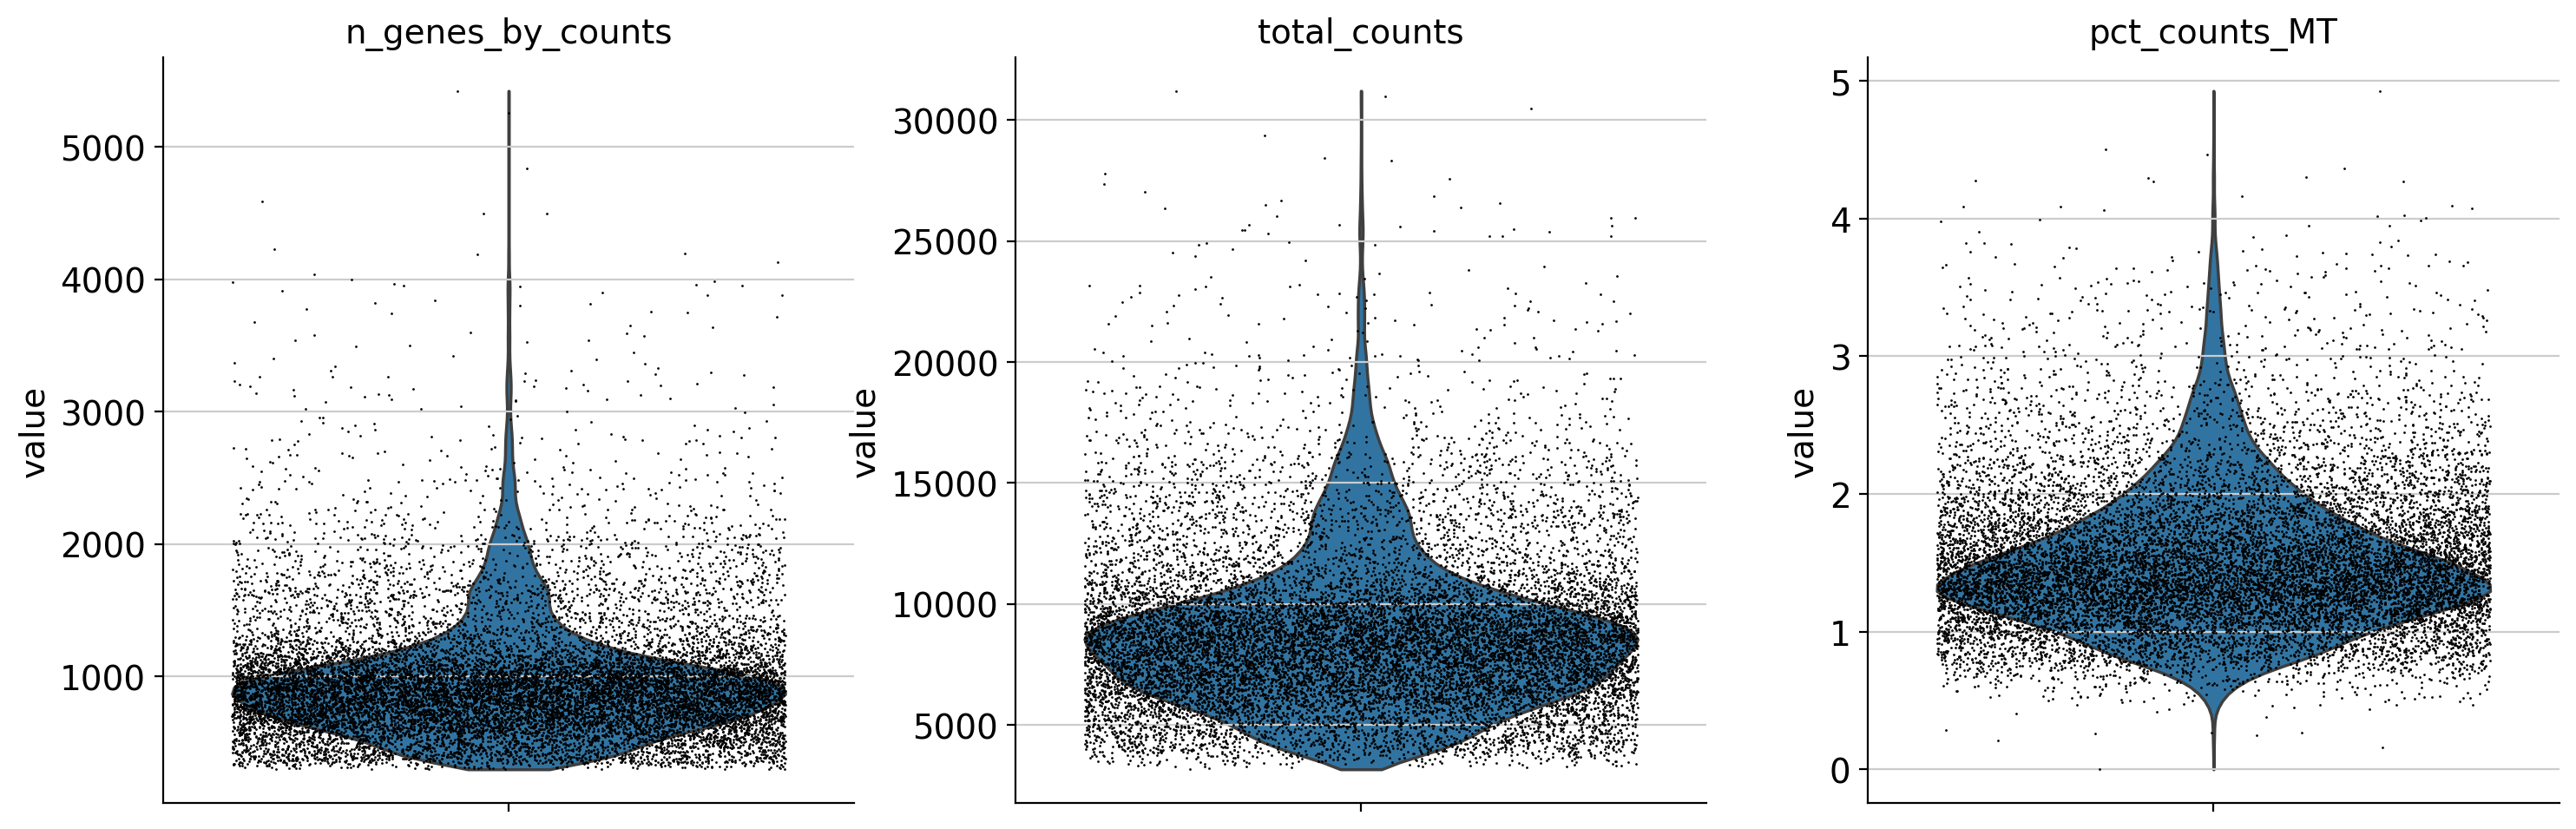

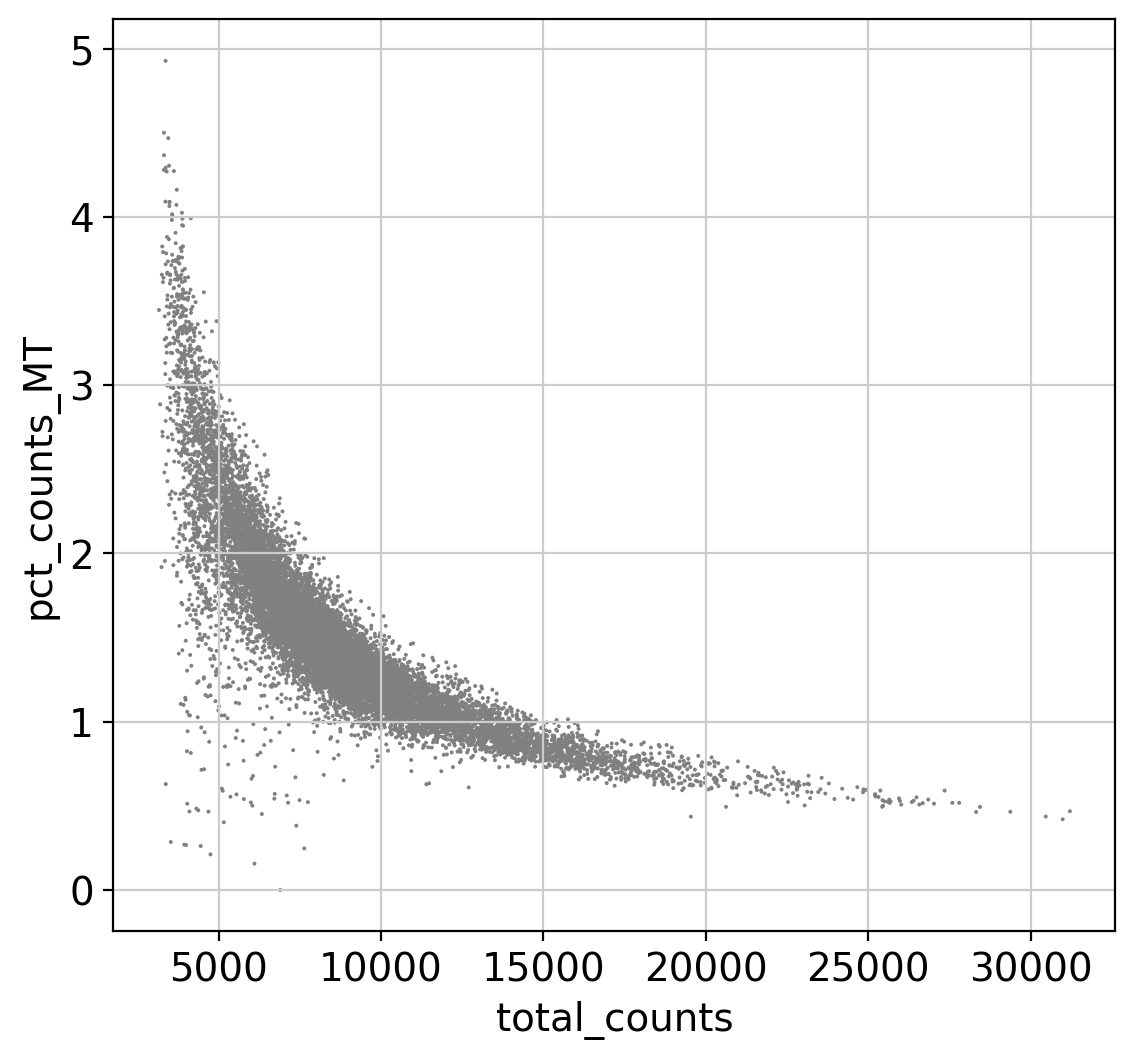

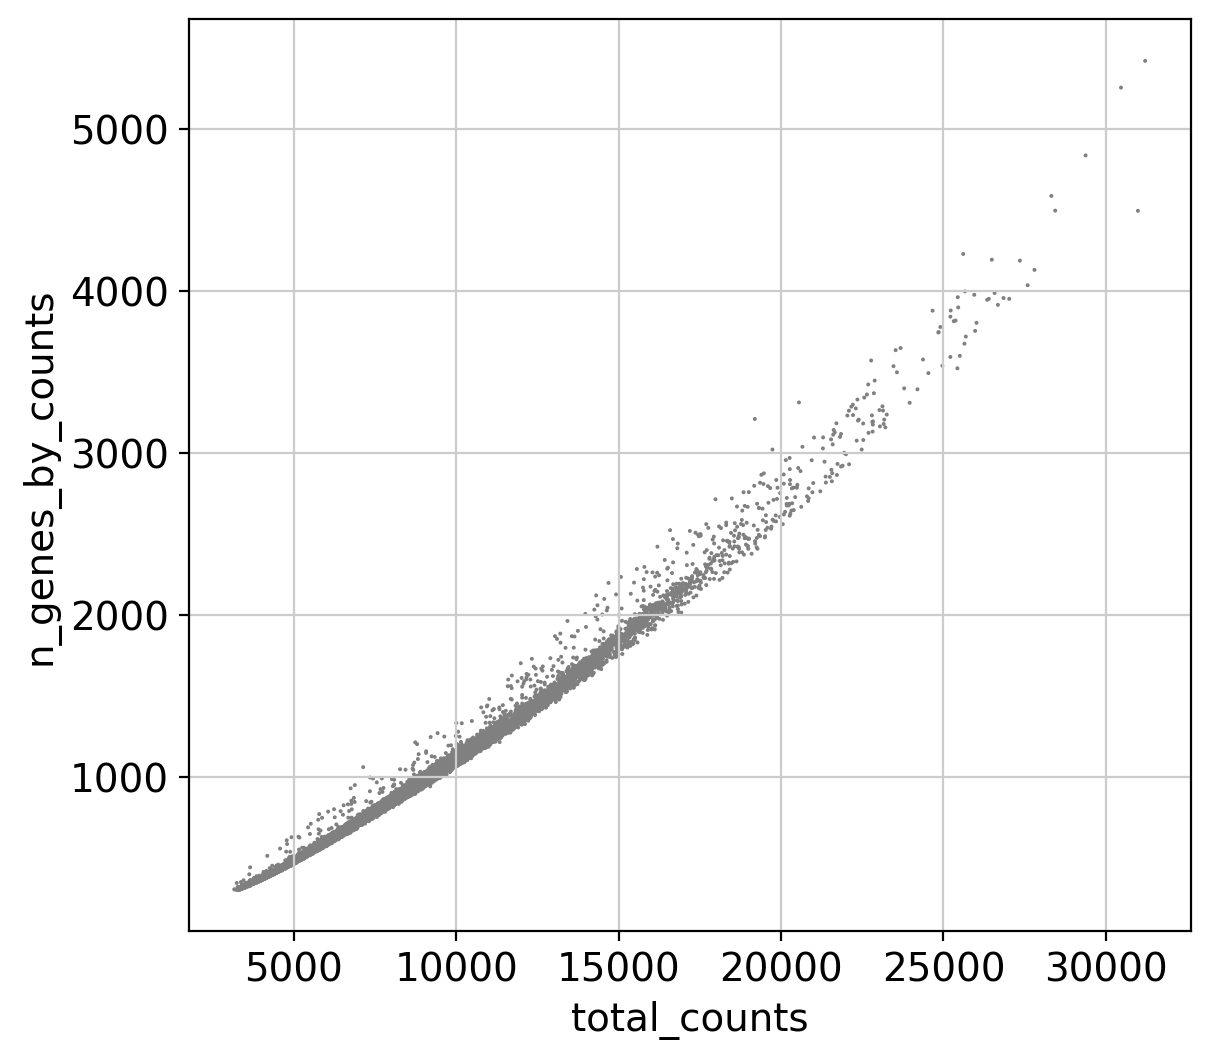

In [12]:
sc.pl.violin(adata, ['n_genes_by_counts','total_counts','pct_counts_MT'], jitter=0.4, multi_panel=True)
sc.pl.scatter(adata, x='total_counts', y='pct_counts_MT')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

## 5. Filter low‑quality cells / genes
Adjust thresholds after looking at QC plots.

In [13]:
# Basic filters
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Mito filter (example <20%)
adata = adata[adata.obs['pct_counts_MT'] < 20, :].copy()
adata

filtered out 2 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 14783 × 17372
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'total_counts_RIBO', 'log1p_total_counts_RIBO',

## 6. Doublet detection (Scrublet)

Running Scrublet
normalizing counts per cell
    finished (0:00:03)
extracting highly variable genes
    finished (0:00:02)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.40
Detected doublet rate = 0.5%
Estimated detectable doublet fraction = 57.7%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.8%
    Scrublet finished (0:04:29)


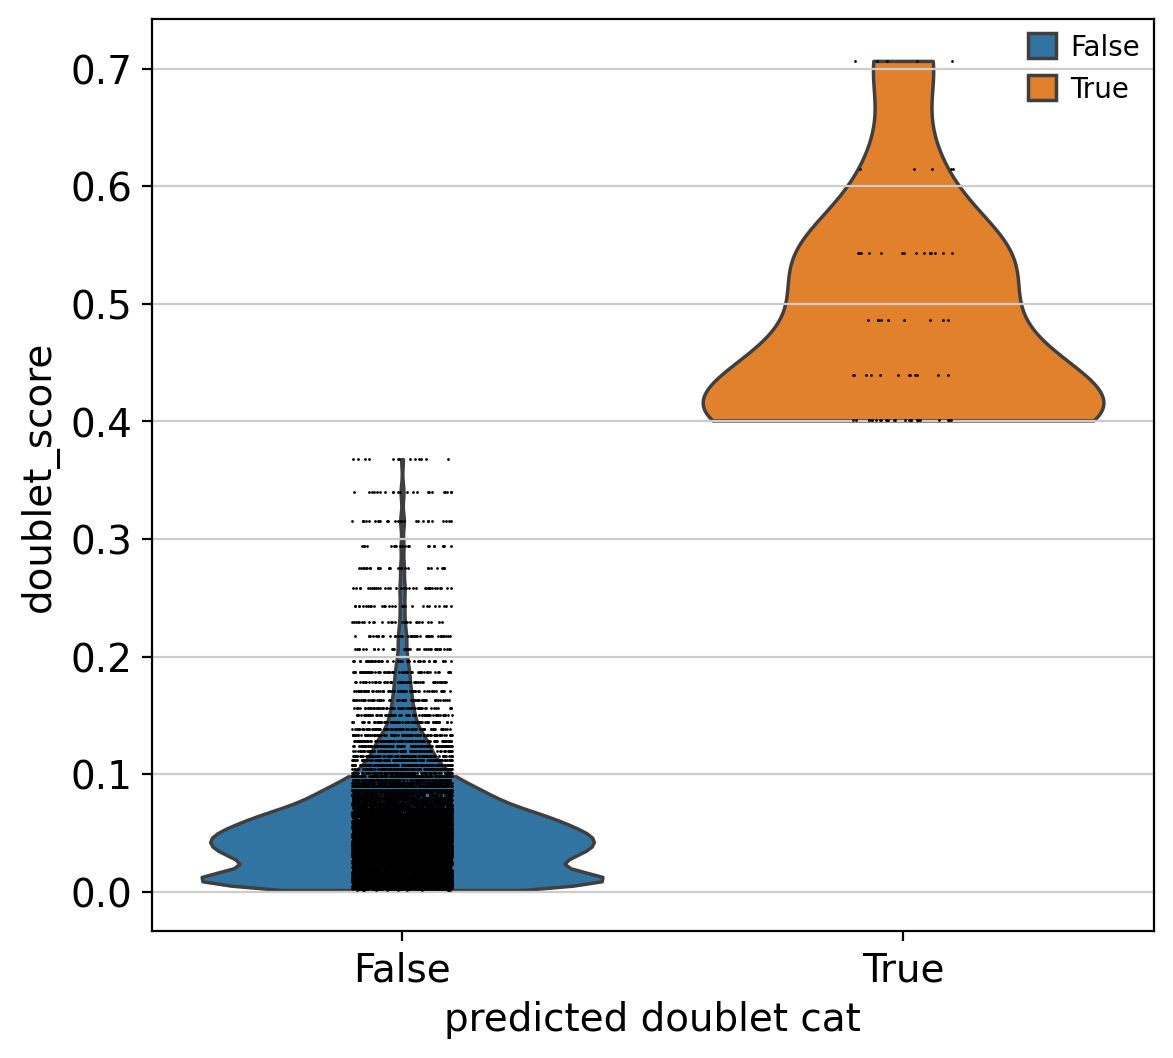

AnnData object with n_obs × n_vars = 14711 × 17372
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'total_counts_RIBO', 'log1p_total_counts_RIBO',

In [14]:
# Run Scrublet
sc.pp.scrublet(adata)

# Make categorical version for plotting
adata.obs['predicted_doublet_cat'] = adata.obs['predicted_doublet'].astype('category')

# Plot violin grouped by categorical version
sc.pl.violin(adata, 'doublet_score', groupby='predicted_doublet_cat')

# Filter doublets using the ORIGINAL boolean
adata = adata[~adata.obs['predicted_doublet']].copy()

adata



## 7. Normalize, log‑transform, store raw

In [15]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata.copy()  # save log‑normalized full matrix

normalizing counts per cell
    finished (0:00:00)


## 8. Highly Variable Genes (HVGs)

extracting highly variable genes


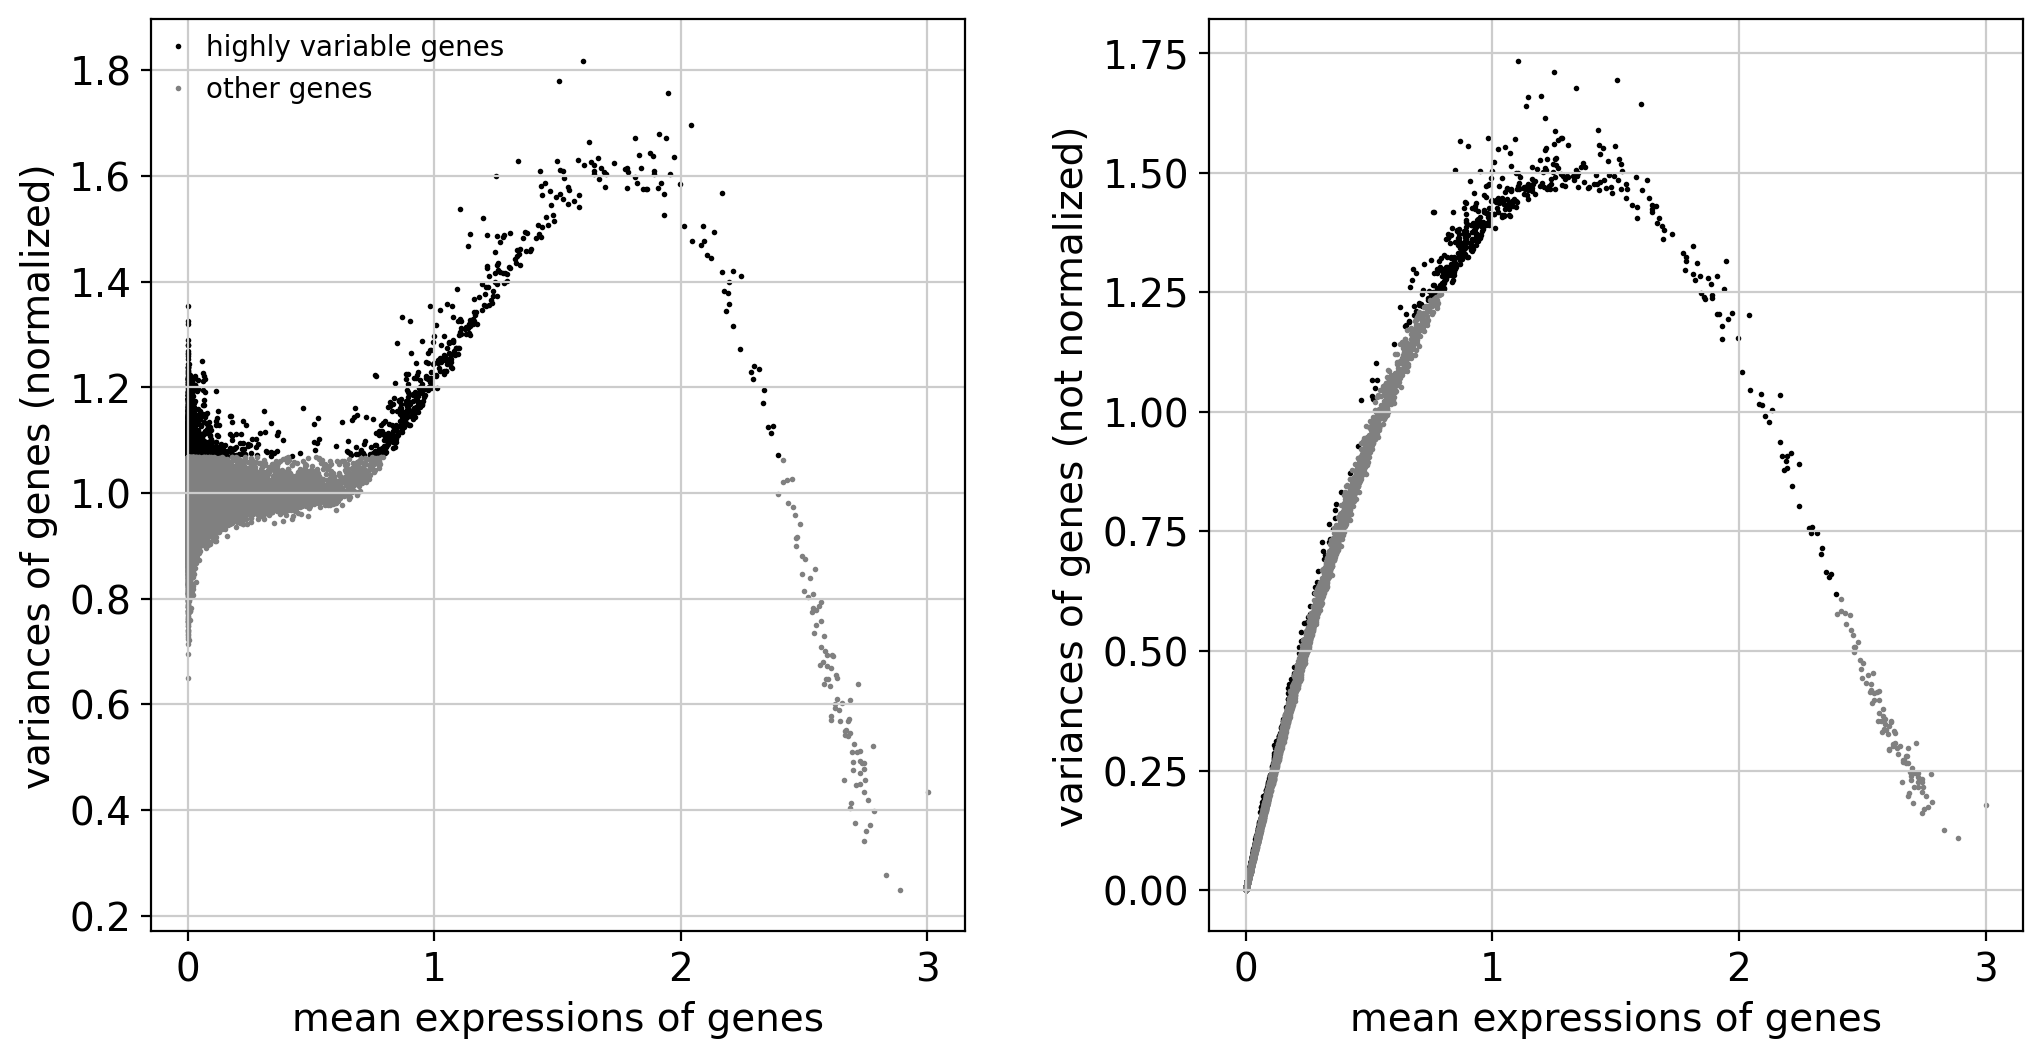

AnnData object with n_obs × n_vars = 14711 × 2000
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'total_counts_RIBO', 'log1p_total_counts_RIBO', 

In [16]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=2000)
sc.pl.highly_variable_genes(adata)

# Subset to HVGs
adata = adata[:, adata.var.highly_variable].copy()
adata

## 9. Regress out unwanted variation (optional) + Scale

In [17]:
# Regress out technical covariates (optional but recommended)
sc.pp.regress_out(adata, ['total_counts','pct_counts_MT'])
sc.pp.scale(adata, max_value=10)

regressing out ['total_counts', 'pct_counts_MT']
    sparse input is densified and may lead to high memory use
    finished (0:00:03)


## 10. PCA

computing PCA
    with n_comps=50
    finished (0:00:08)


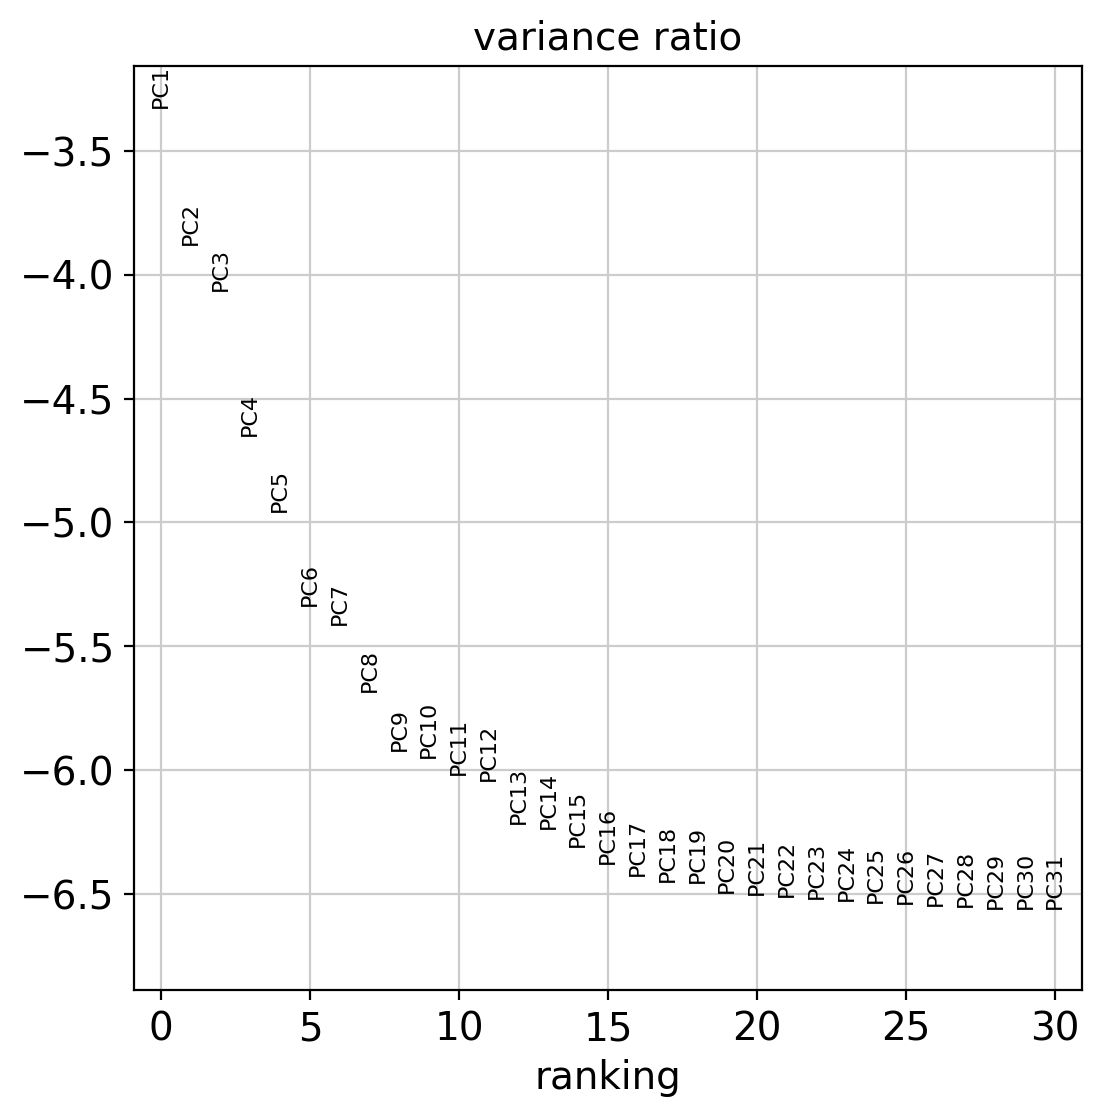

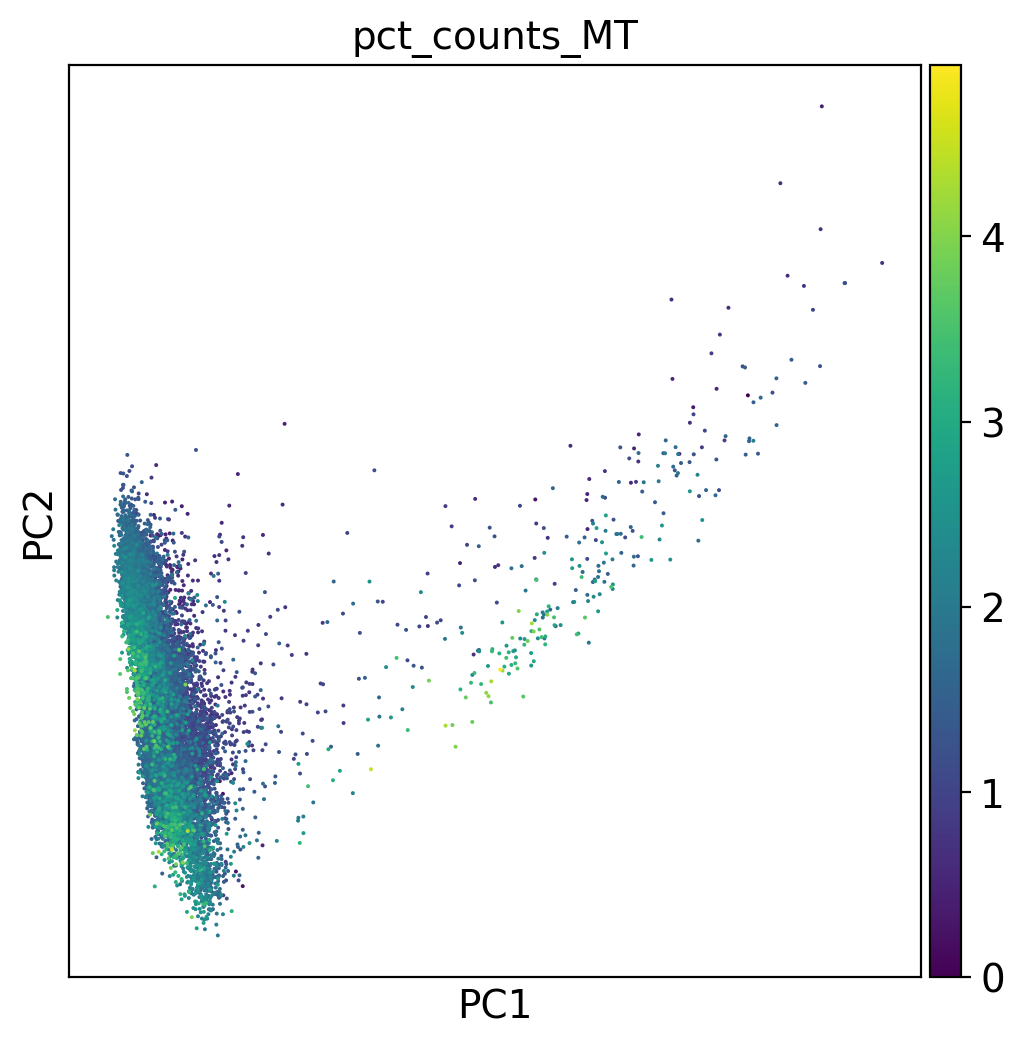

In [18]:
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)
sc.pl.pca_variance_ratio(adata, log=True)
sc.pl.pca(adata, color='pct_counts_MT')

## 11. Neighbors, UMAP, Leiden clustering

computing neighbors
    finished (0:00:34)
computing UMAP
    finished (0:00:14)
running Leiden clustering
    finished (0:00:13)


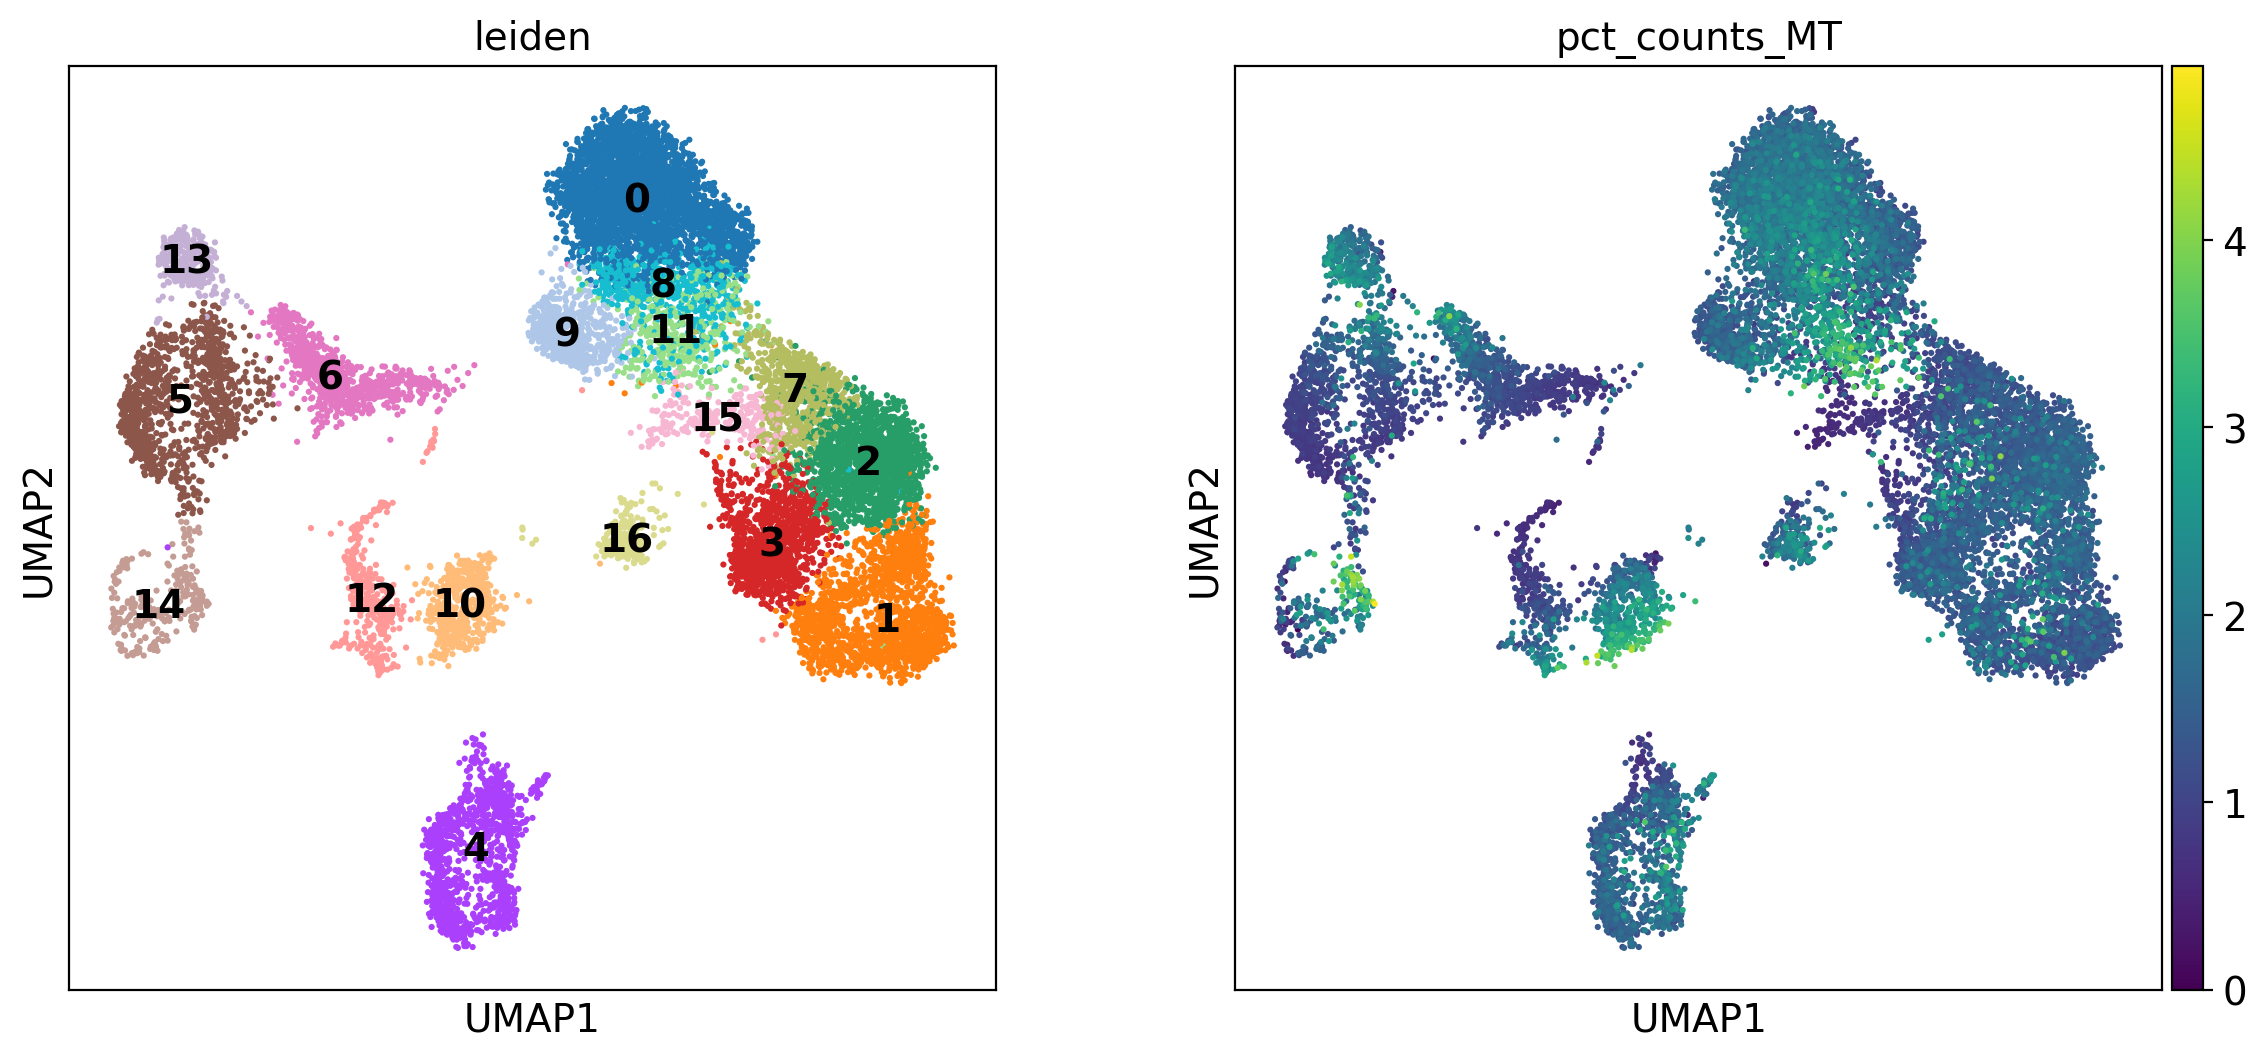

In [19]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, use_rep='X_pca')
sc.tl.umap(adata, random_state=0)
sc.tl.leiden(adata, resolution=1.0, key_added='leiden')

sc.pl.umap(adata, color=['leiden','pct_counts_MT'], legend_loc='on data', size=20)

## 12. Marker genes (DEGs) per cluster

ranking genes
    finished (0:00:30)


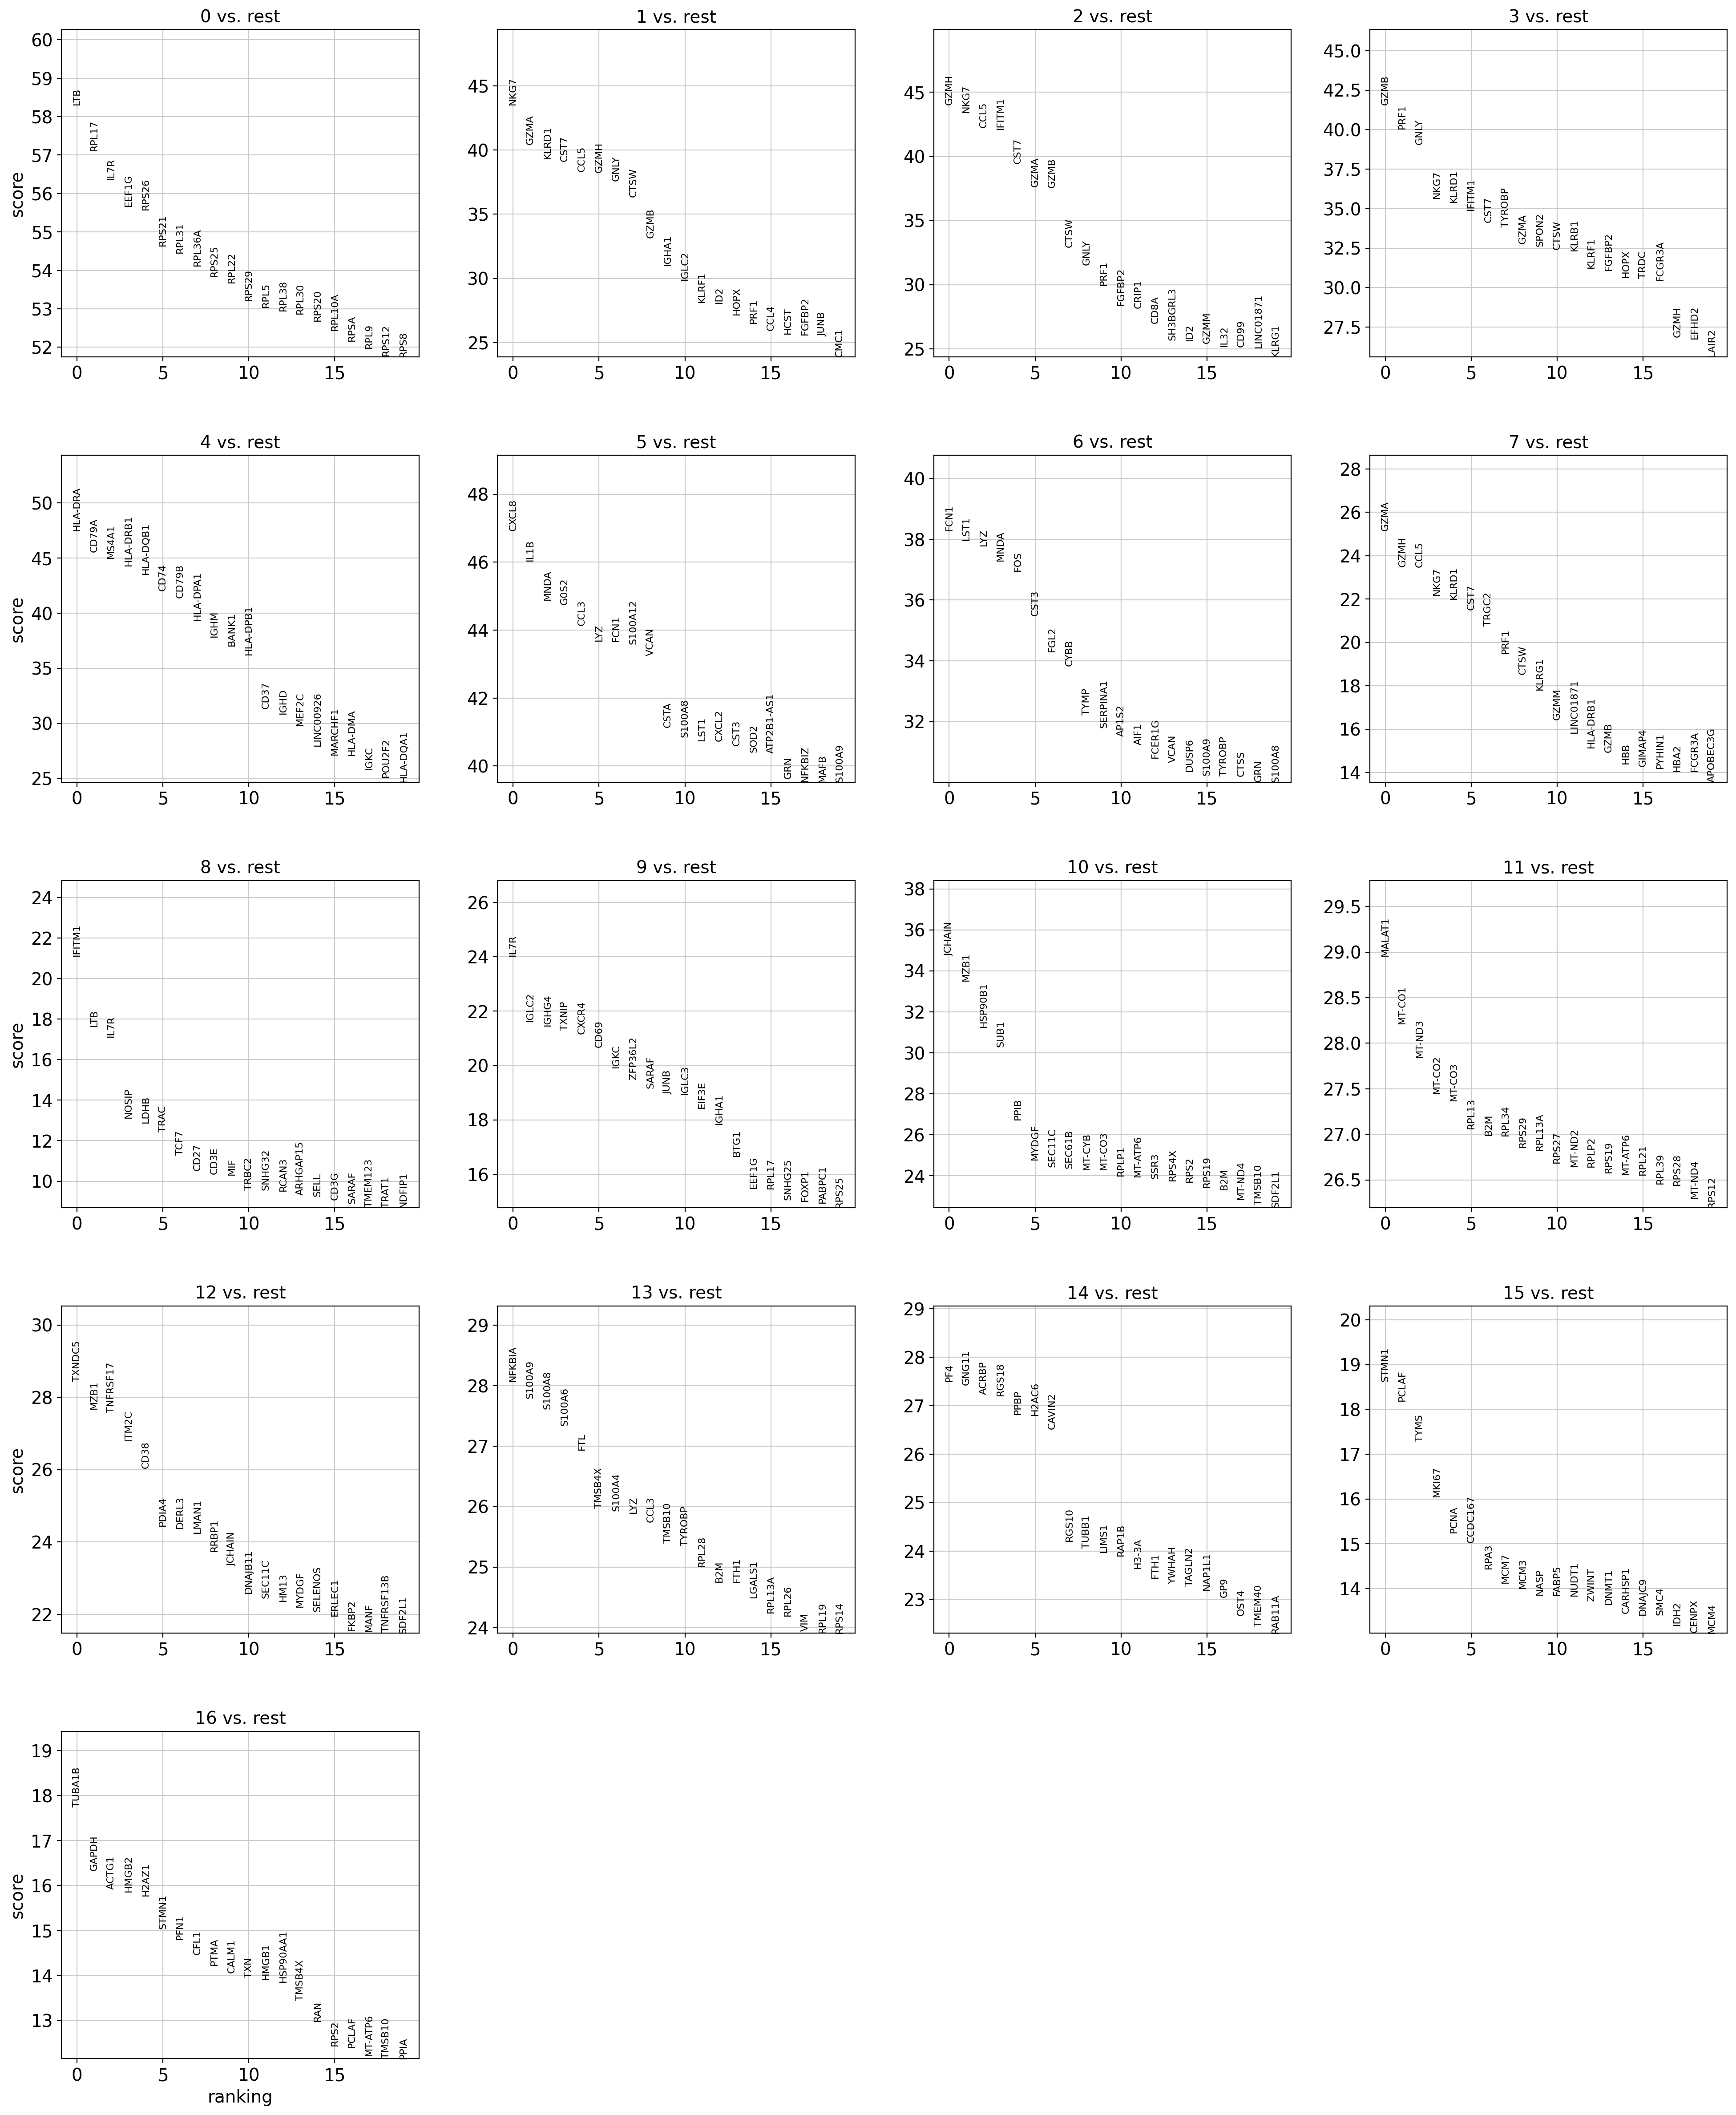

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,LTB,58.300865,3.119145,0.0,0.0
1,0,RPL17,57.107273,0.836972,0.0,0.0
2,0,IL7R,56.362453,3.523813,0.0,0.0
3,0,EEF1G,55.668179,1.906357,0.0,0.0
4,0,RPS26,55.567299,1.220205,0.0,0.0


In [20]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon', use_raw=True)
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)
markers = sc.get.rank_genes_groups_df(adata, group=None)
markers.head()

### 12b. Save markers table

In [21]:
markers.to_csv('rank_genes_groups_full.csv', index=False)
print('saved rank_genes_groups_full.csv')

saved rank_genes_groups_full.csv


## 13. Manual annotation (fill in your mapping)
Paste your cluster→cell type dictionary here. I left your short labels from our earlier step.

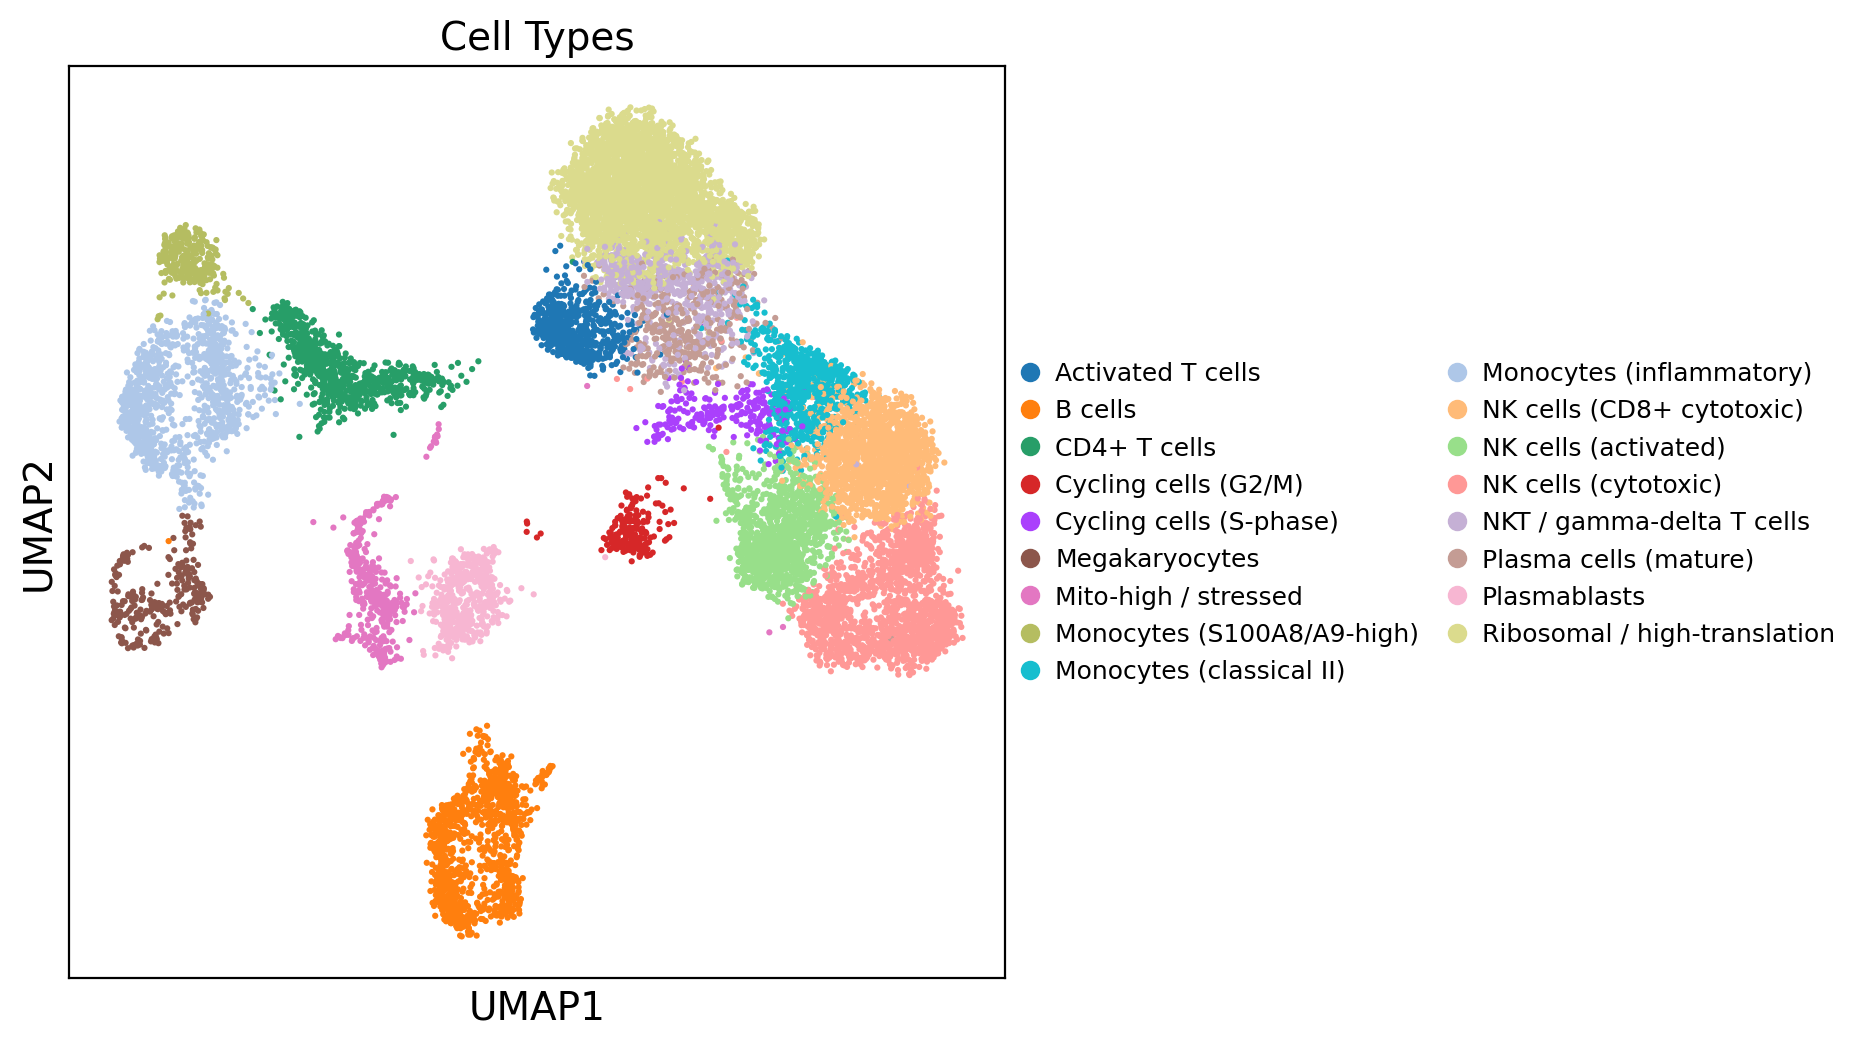

In [22]:
# 1. Ensure leiden labels are strings to match your dictionary keys
adata.obs["leiden"] = adata.obs["leiden"].astype(str)

# 2. Full cluster annotations (your version)
cluster_annotations = {
    "0": "Ribosomal / high-translation",
    "1": "NK cells (cytotoxic)",
    "2": "NK cells (CD8+ cytotoxic)",
    "3": "NK cells (activated)",
    "4": "B cells",
    "5": "Monocytes (inflammatory)",
    "6": "CD4+ T cells",
    "7": "Monocytes (classical II)",
    "8": "NKT / gamma-delta T cells",
    "9": "Activated T cells",
    "10": "Plasmablasts",
    "11": "Plasma cells (mature)",
    "12": "Mito-high / stressed",
    "13": "Monocytes (S100A8/A9-high)",
    "14": "Megakaryocytes",
    "15": "Cycling cells (S-phase)",
    "16": "Cycling cells (G2/M)"
}

# 3. Assign cell type labels
adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_annotations)

# 4. Convert to categorical (important for Scanpy legends)
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

# 5. Plot UMAP with full names in the right margin
sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="right margin",
    legend_fontsize=9,
    legend_fontoutline=1,
    title="Cell Types",
    size=20,
)

## 14. Top markers per cell type + DotPlot / Violin

In [23]:
# Rank genes per cell type
sc.tl.rank_genes_groups(adata, groupby='cell_type', method='wilcoxon', use_raw=True)
ct_markers = sc.get.rank_genes_groups_df(adata, group=None)

# Take top 5 per cell type
top_n = 5
top_markers = ct_markers.groupby('group').head(top_n)
genes_to_plot = top_markers['names'].unique().tolist()
genes_to_plot

ranking genes
    finished (0:00:28)


['IL7R',
 'IGLC2',
 'IGHG4',
 'TXNIP',
 'CXCR4',
 'HLA-DRA',
 'CD79A',
 'MS4A1',
 'HLA-DRB1',
 'HLA-DQB1',
 'FCN1',
 'LST1',
 'LYZ',
 'MNDA',
 'FOS',
 'TUBA1B',
 'GAPDH',
 'ACTG1',
 'HMGB2',
 'H2AZ1',
 'STMN1',
 'PCLAF',
 'TYMS',
 'MKI67',
 'PCNA',
 'PF4',
 'GNG11',
 'ACRBP',
 'RGS18',
 'PPBP',
 'TXNDC5',
 'MZB1',
 'TNFRSF17',
 'ITM2C',
 'CD38',
 'NFKBIA',
 'S100A9',
 'S100A8',
 'S100A6',
 'FTL',
 'GZMA',
 'GZMH',
 'CCL5',
 'NKG7',
 'KLRD1',
 'CXCL8',
 'IL1B',
 'G0S2',
 'CCL3',
 'IFITM1',
 'CST7',
 'GZMB',
 'PRF1',
 'GNLY',
 'LTB',
 'NOSIP',
 'LDHB',
 'MALAT1',
 'MT-CO1',
 'MT-ND3',
 'MT-CO2',
 'MT-CO3',
 'JCHAIN',
 'HSP90B1',
 'SUB1',
 'PPIB',
 'RPL17',
 'EEF1G',
 'RPS26']

In [24]:
print("Automatically generating marker gene dictionary...")

# Generate DEGs for each cell type
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")

# Build dictionary automatically
marker_genes_dict = {}

for ct in adata.obs["cell_type"].unique():
    df = sc.get.rank_genes_groups_df(adata, group=ct)
    top_genes = df["names"].head(5).tolist()   # top 5 markers
    marker_genes_dict[ct] = top_genes

print("Done. Marker genes per cell type:")
for k, v in marker_genes_dict.items():
    print(f"{k}: {v}")


Automatically generating marker gene dictionary...
ranking genes
    finished (0:00:29)
Done. Marker genes per cell type:
Monocytes (inflammatory): ['CXCL8', 'IL1B', 'MNDA', 'G0S2', 'CCL3']
NK cells (CD8+ cytotoxic): ['GZMH', 'NKG7', 'CCL5', 'IFITM1', 'CST7']
Ribosomal / high-translation: ['LTB', 'RPL17', 'IL7R', 'EEF1G', 'RPS26']
NK cells (cytotoxic): ['NKG7', 'GZMA', 'KLRD1', 'CST7', 'CCL5']
Plasma cells (mature): ['MALAT1', 'MT-CO1', 'MT-ND3', 'MT-CO2', 'MT-CO3']
B cells: ['HLA-DRA', 'CD79A', 'MS4A1', 'HLA-DRB1', 'HLA-DQB1']
Megakaryocytes: ['PF4', 'GNG11', 'ACRBP', 'RGS18', 'PPBP']
Activated T cells: ['IL7R', 'IGLC2', 'IGHG4', 'TXNIP', 'CXCR4']
NKT / gamma-delta T cells: ['IFITM1', 'LTB', 'IL7R', 'NOSIP', 'LDHB']
Mito-high / stressed: ['TXNDC5', 'MZB1', 'TNFRSF17', 'ITM2C', 'CD38']
Plasmablasts: ['JCHAIN', 'MZB1', 'HSP90B1', 'SUB1', 'PPIB']
Monocytes (classical II): ['GZMA', 'GZMH', 'CCL5', 'NKG7', 'KLRD1']
Cycling cells (S-phase): ['STMN1', 'PCLAF', 'TYMS', 'MKI67', 'PCNA']
NK cel

In [25]:
def map_to_lineage(x):
    if "B cell" in x:
        return "B cells"
    if "Plasma" in x:
        return "B cells"
    if "NK" in x or "NKT" in x:
        return "NK cells"
    if "T cells" in x or "Activated T" in x:
        return "T cells"
    if "Monocyte" in x:
        return "Monocytes"
    if "Mega" in x:
        return "Megakaryocytes"
    if "Cycling" in x:
        return "Cycling"
    if "Mito" in x:
        return "Mito-high"
    if "Ribosomal" in x:
        return "Ribosomal"
    return "Other"

adata.obs["lineage"] = adata.obs["cell_type"].apply(map_to_lineage)
adata.obs["lineage"] = adata.obs["lineage"].astype("category")


In [26]:
# STEP 2 — Generate marker dict for lineage-level groups

# Recompute DEGs for lineage groups (mandatory!)
sc.tl.rank_genes_groups(adata, groupby="lineage", method="wilcoxon")

marker_genes_dict = {}

for lineage in adata.obs["lineage"].unique():
    df = sc.get.rank_genes_groups_df(adata, group=lineage)
    marker_genes_dict[lineage] = df["names"].head(5).tolist()

marker_genes_dict


ranking genes
    finished (0:00:27)


{'Monocytes': ['LYZ', 'G0S2', 'CXCL8', 'IL1B', 'CCL3'],
 'NK cells': ['NKG7', 'CST7', 'IFITM1', 'GZMA', 'GZMB'],
 'Ribosomal': ['LTB', 'RPL17', 'IL7R', 'EEF1G', 'RPS26'],
 'B cells': ['CD79A', 'MS4A1', 'IGHM', 'IGKC', 'CD79B'],
 'Megakaryocytes': ['PF4', 'GNG11', 'ACRBP', 'RGS18', 'PPBP'],
 'T cells': ['S100A9', 'FOS', 'FCN1', 'LYZ', 'S100A8'],
 'Mito-high': ['TXNDC5', 'MZB1', 'TNFRSF17', 'ITM2C', 'CD38'],
 'Cycling': ['STMN1', 'PCLAF', 'TUBA1B', 'HMGB2', 'PCNA']}

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_lineage']`


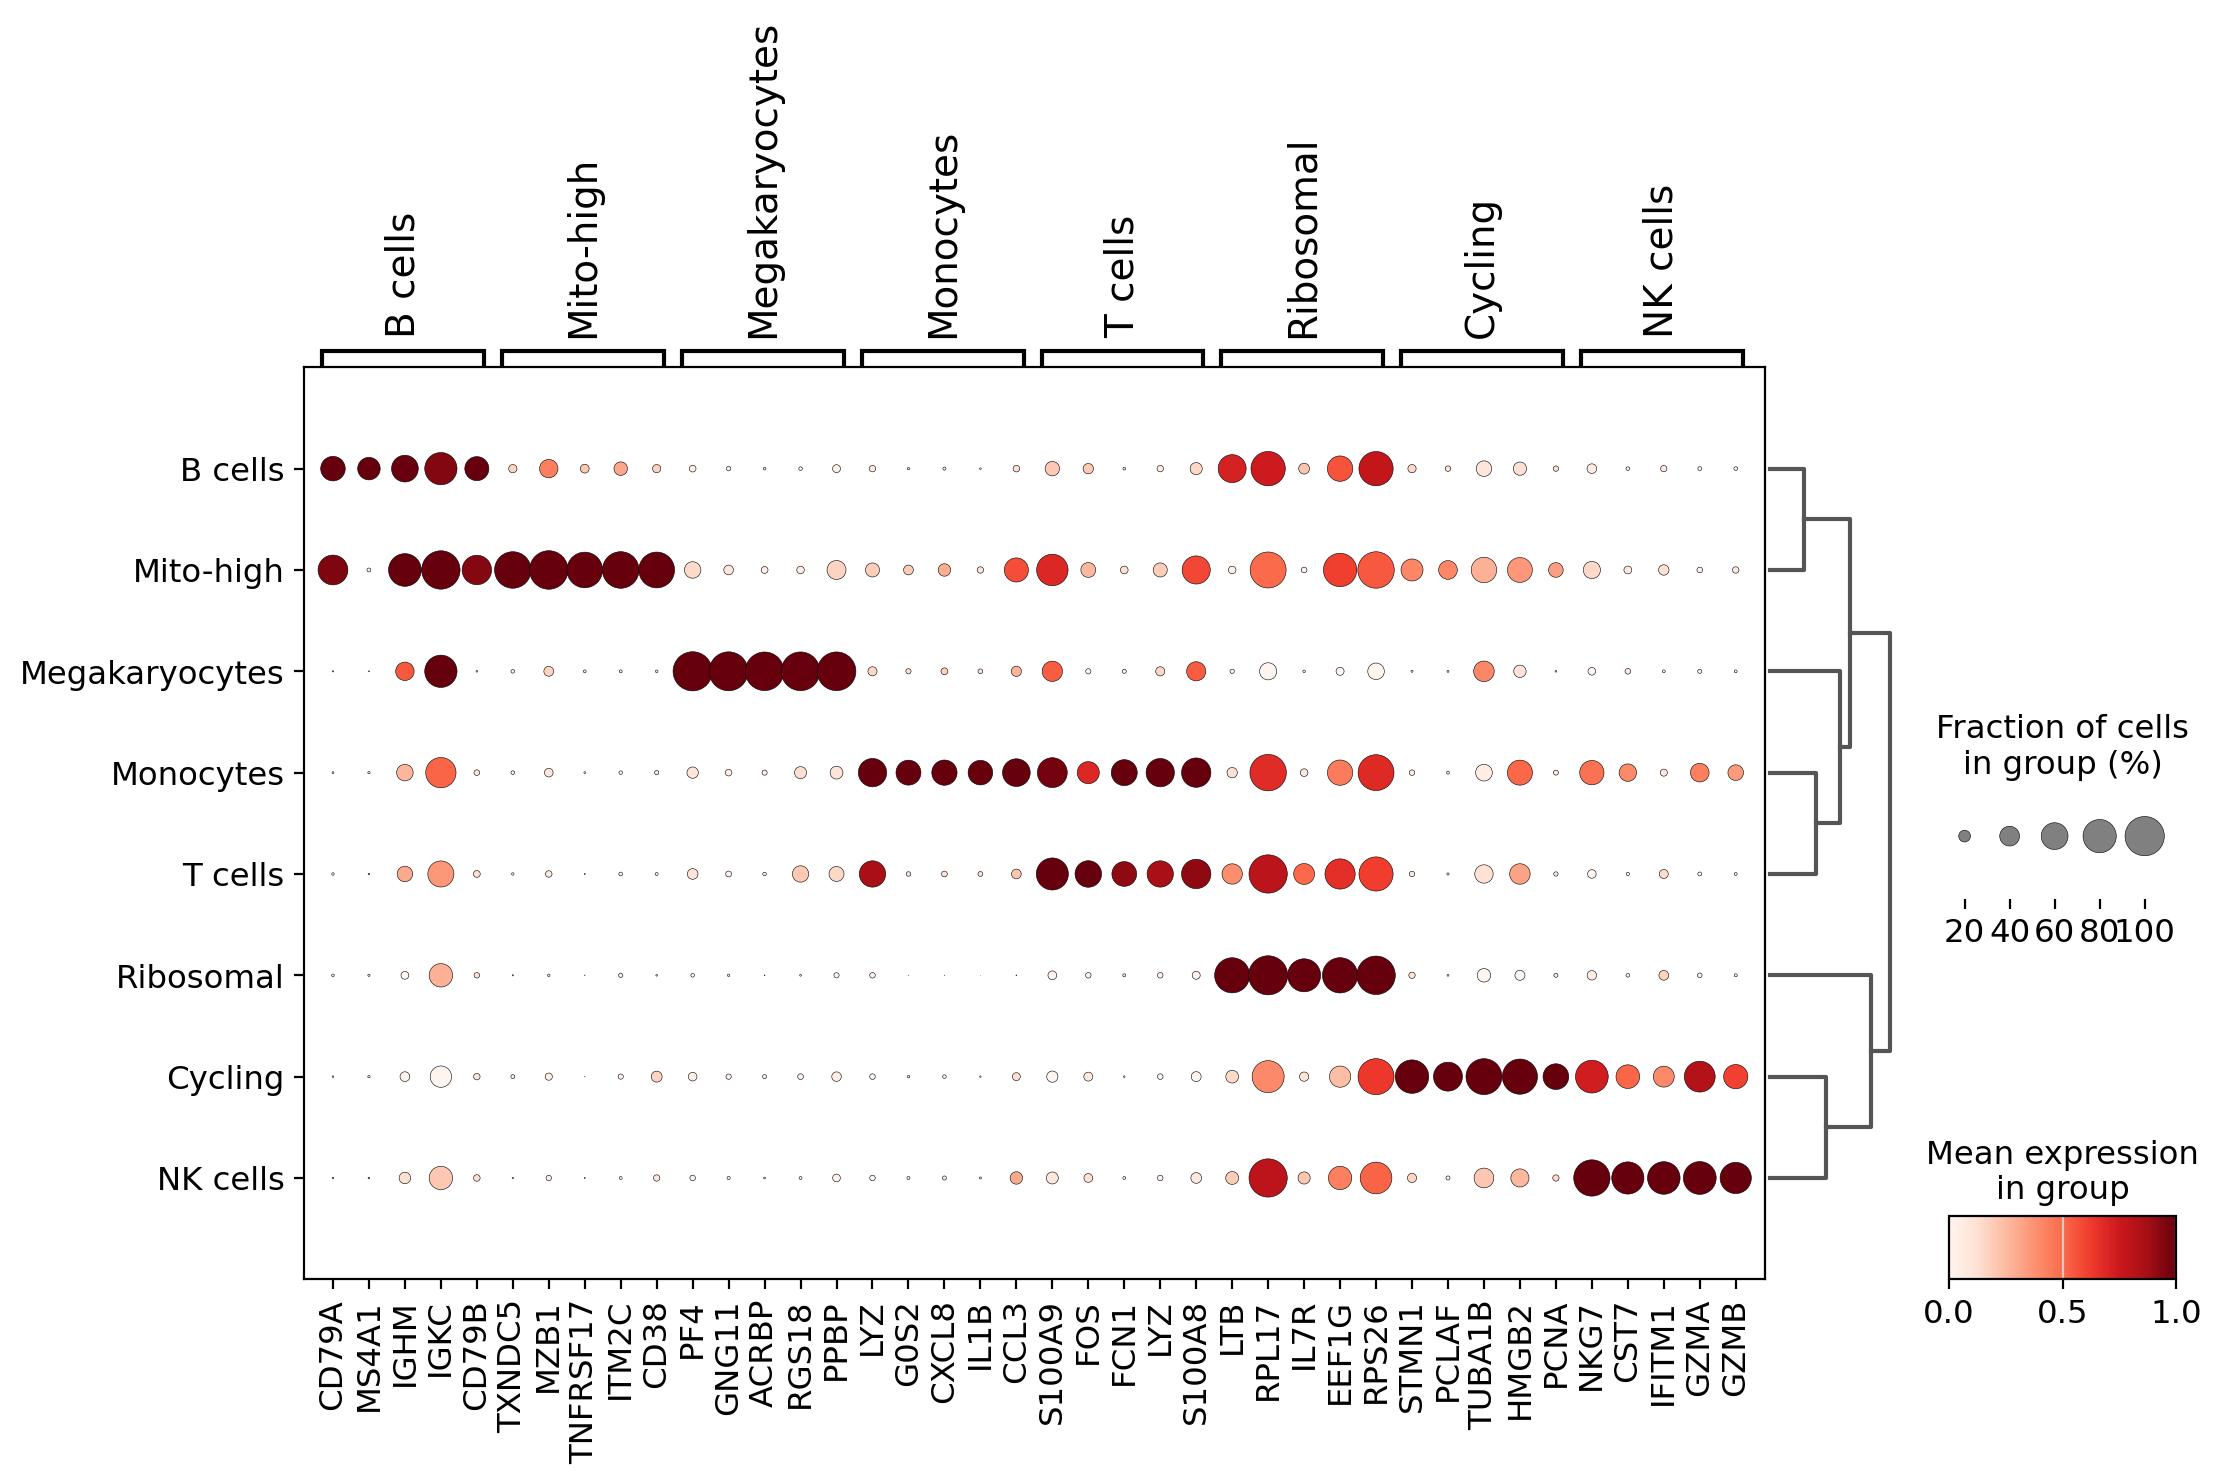

In [27]:
sc.tl.dendrogram(adata, groupby="lineage")

sc.pl.dotplot(
    adata,
    var_names=marker_genes_dict,
    groupby="lineage",
    dendrogram=True,
    standard_scale="var",
    figsize=(12, 6)
)


Plotting stacked violin...
    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_lineage']`


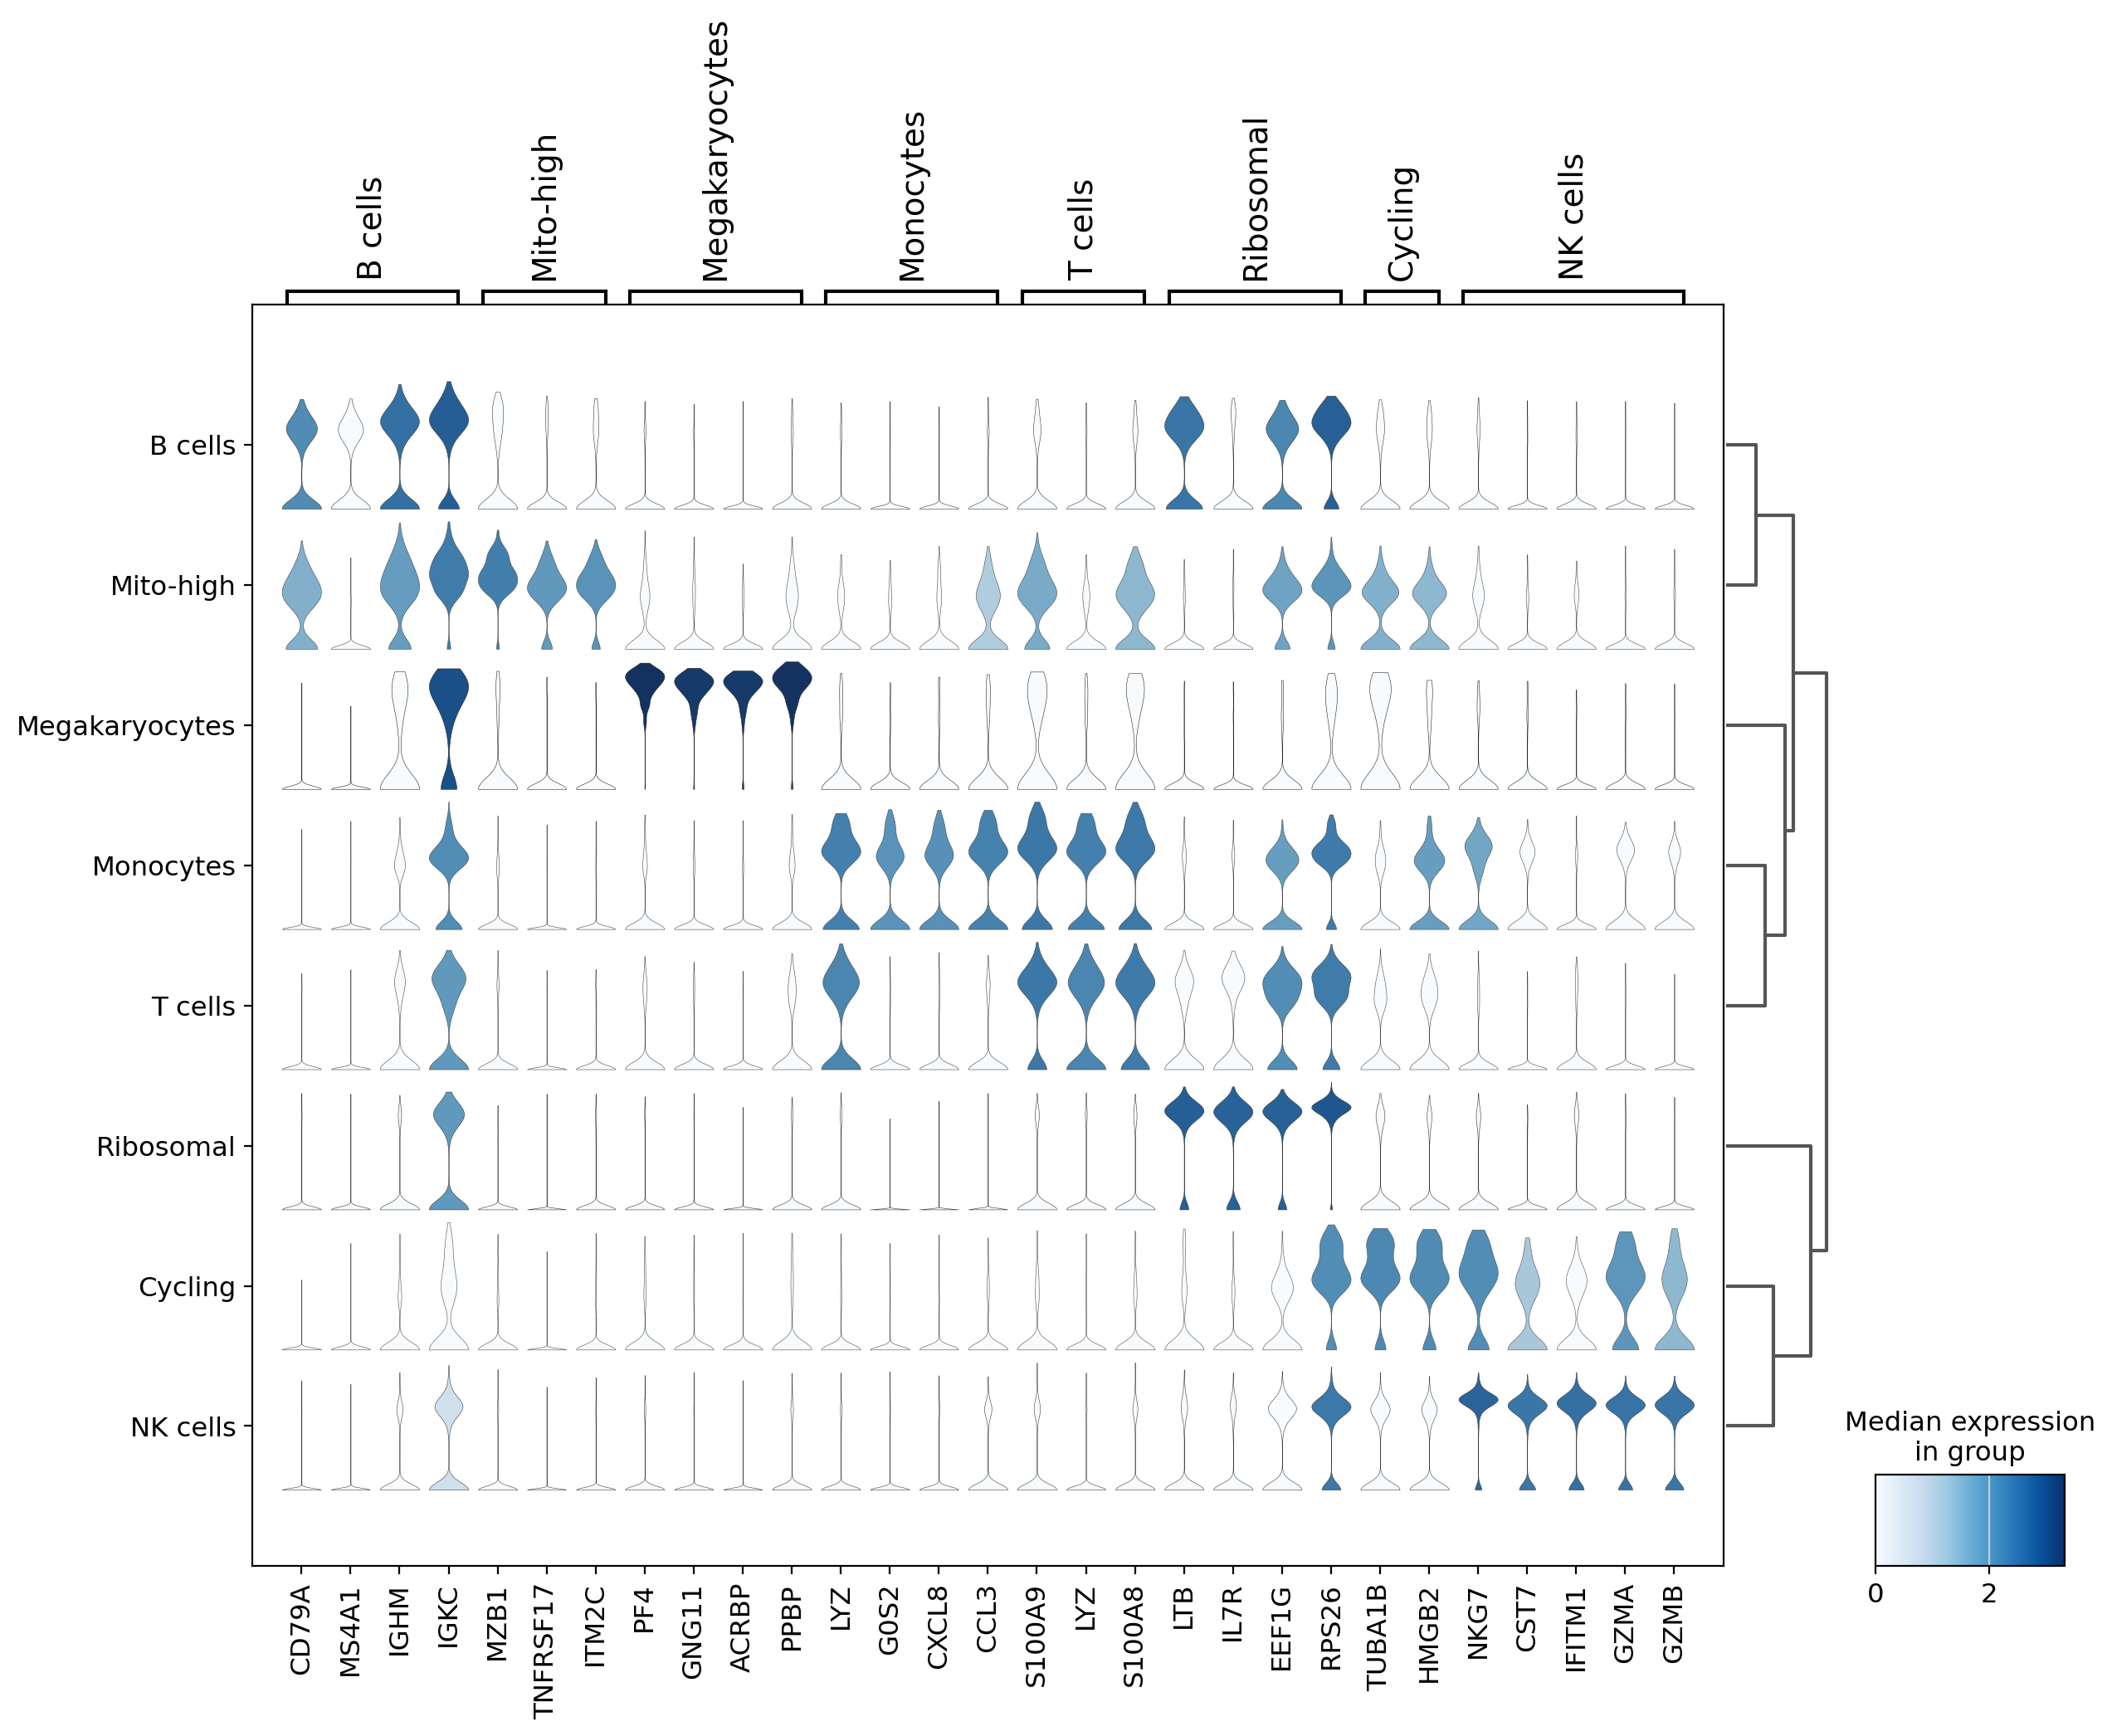

In [28]:
print("Plotting stacked violin...")

# Clean gene lists
marker_genes_dict = {
    k: [g for g in v if g in adata.var_names]
    for k, v in marker_genes_dict.items()
}

sc.tl.dendrogram(adata, groupby="lineage")  # safe to run again

sc.pl.stacked_violin(
    adata,
    marker_genes_dict,
    groupby="lineage",
    dendrogram=True,
    figsize=(14, 10)
)
